<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 21</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Detecting &amp; Treating Outliers <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos: flag points with the IQR fence, watch a z-score hide its own outlier while the robust modified z catches it, see one leverage point swing a regression line, cap and winsorize, and meet a multivariate outlier no single column can see.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | The IQR fence | Tukey 1.5xIQR flags points, robustly |
| 2 | When z hides | a z-score masks its own outlier; modified z catches it |
| 3 | One point, big swing | a leverage point drags an OLS line |
| 4 | Cap, don't cut | winsorize to limit influence without deleting |
| 5 | Hidden in plain sight | a multivariate outlier no column sees alone |

> The treatment depends on the CAUSE: error, genuine extreme, or signal. Detecting is only step one.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(21)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE IQR FENCE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚧 Tukey's 1.5x rule, robustly</div>
<div style="color:#4a5578;margin-top:6px">The box-plot rule from Chapter 9: anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged. It uses quartiles, so it is robust and makes no normality assumption. Note: flagged is not the same as wrong, the rule flags about 0.7% of perfectly normal data by design.</div>
</div>

Q1=15.0  Q3=19.0  IQR=4.0
fences: [9.0, 25.0]
flagged outliers: [95]


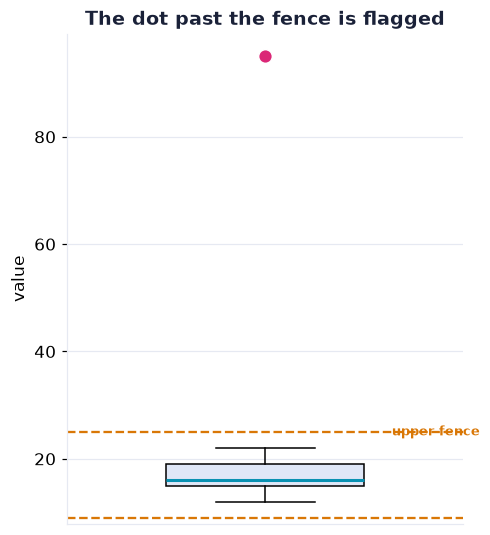

In [2]:
data = pd.Series([12, 14, 14, 15, 15, 16, 16, 17, 18, 19, 21, 22, 95])   # 95 is the suspect
q1, q3 = data.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
flagged = data[(data < lo) | (data > hi)]
print(f"Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}")
print(f"fences: [{lo:.1f}, {hi:.1f}]")
print(f"flagged outliers: {list(flagged)}")

fig, ax = plt.subplots(figsize=(4.6, 5))
bp = ax.boxplot(data, widths=0.5, patch_artist=True,
                flierprops=dict(marker="o", markerfacecolor=PINK, markersize=9, markeredgecolor="white"))
bp["boxes"][0].set_facecolor("#dfe7f7"); bp["medians"][0].set_color(CYAN); bp["medians"][0].set_linewidth(2)
ax.axhline(lo, color=AMBER, ls="--", lw=1.5); ax.axhline(hi, color=AMBER, ls="--", lw=1.5)
ax.text(1.32, hi, "upper fence", color=AMBER, fontsize=8.5, fontweight="bold", va="center")
ax.set_xticks([]); ax.set_ylabel("value"); ax.set_title("The dot past the fence is flagged")
plt.tight_layout(); plt.show()

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · WHEN Z HIDES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎭 Masking, and the robust fix</div>
<div style="color:#4a5578;margin-top:6px">The plain z-score is not robust: a big outlier inflates the standard deviation so much that its own z falls under 3 and it hides (masking). The modified z-score, built on the median and MAD (Chapter 12), is immune and flags it decisively.</div>
</div>

SD inflated by the outlier   : 298.8
plain z of the 1000          : 3.00   -> |z|>3 ? False  (MASKED!)
modified z of the 1000       : 671.8  -> |M|>3.5 ? True  (caught)

after removing it: mean 4.0 (was 103.6), SD 1.15 (was 298.8)


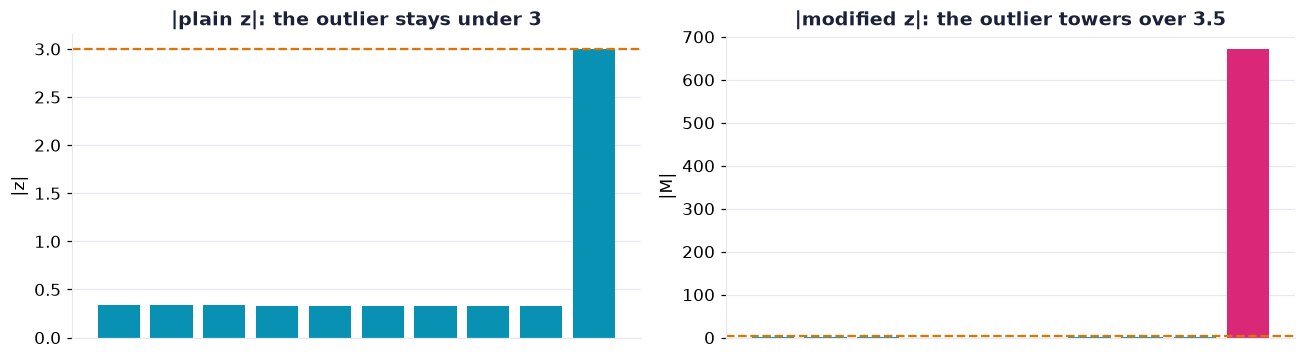

In [3]:
x = np.array([2, 3, 3, 4, 4, 4, 5, 5, 6, 1000.0])   # the 1000 is a blatant error

z = (x - x.mean()) / x.std()
med = np.median(x)
mad = np.median(np.abs(x - med))
mod_z = 0.6745 * (x - med) / mad      # 0.6745 puts MAD on the SD scale

print(f"SD inflated by the outlier   : {x.std():.1f}")
print(f"plain z of the 1000          : {z[-1]:.2f}   -> |z|>3 ? {abs(z[-1])>3}  (MASKED!)")
print(f"modified z of the 1000       : {mod_z[-1]:.1f}  -> |M|>3.5 ? {abs(mod_z[-1])>3.5}  (caught)")
print(f"\nafter removing it: mean {x[:-1].mean():.1f} (was {x.mean():.1f}), SD {x[:-1].std():.2f} (was {x.std():.1f})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.4))
idx = np.arange(len(x))
a1.bar(idx, np.abs(z), color=[PINK if abs(v)>3 else CYAN for v in z]); a1.axhline(3, color=AMBER, ls="--")
a1.set_title("|plain z|: the outlier stays under 3"); a1.set_ylabel("|z|"); a1.set_xticks([])
a2.bar(idx, np.abs(mod_z), color=[PINK if abs(v)>3.5 else CYAN for v in mod_z]); a2.axhline(3.5, color=AMBER, ls="--")
a2.set_title("|modified z|: the outlier towers over 3.5"); a2.set_ylabel("|M|"); a2.set_xticks([])
plt.tight_layout(); plt.show()

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · ONE POINT, BIG SWING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📈 A leverage point bends the line</div>
<div style="color:#4a5578;margin-top:6px">Outliers do not just distort summaries, they can swing a model. A single high-leverage point in a scatter pulls the least-squares regression line toward itself. Fit with it and without it, and watch the slope change.</div>
</div>

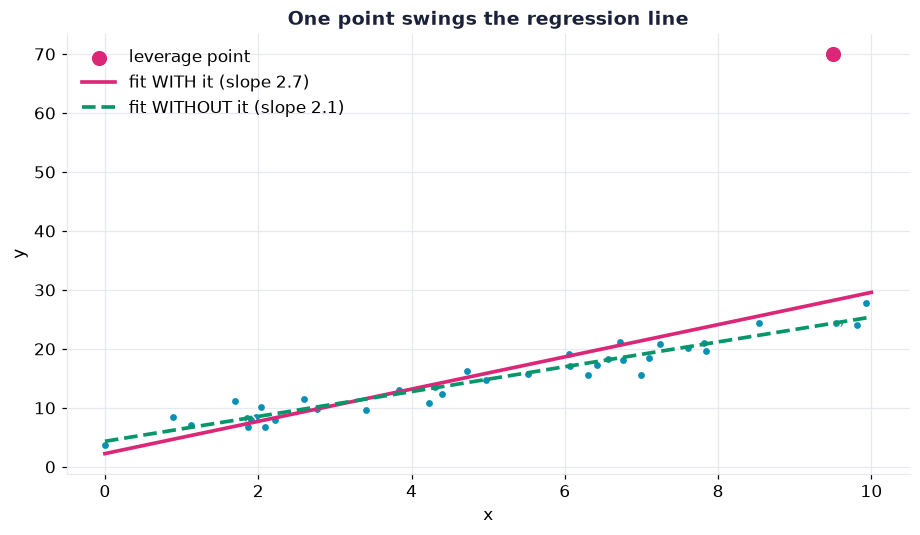

slope with the point: 2.73   without it: 2.11
Investigate before deleting: a real point that bends the line may be the most important one.


In [4]:
xs = rng.uniform(0, 10, 40)
ys = 2*xs + 5 + rng.normal(0, 2, 40)
xs = np.append(xs, 9.5); ys = np.append(ys, 70)        # one leverage point far off the trend

m_all, b_all = np.polyfit(xs, ys, 1)
m_no,  b_no  = np.polyfit(xs[:-1], ys[:-1], 1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(xs[:-1], ys[:-1], color=CYAN, s=30, edgecolor="white")
ax.scatter([xs[-1]],[ys[-1]], color=PINK, s=120, edgecolor="white", zorder=5, label="leverage point")
gx = np.array([0, 10])
ax.plot(gx, m_all*gx+b_all, color=PINK, lw=2.4, label=f"fit WITH it (slope {m_all:.1f})")
ax.plot(gx, m_no*gx+b_no,  color=GREEN, lw=2.4, ls="--", label=f"fit WITHOUT it (slope {m_no:.1f})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("One point swings the regression line"); ax.legend()
plt.tight_layout(); plt.show()
print(f"slope with the point: {m_all:.2f}   without it: {m_no:.2f}")
print("Investigate before deleting: a real point that bends the line may be the most important one.")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · CAP, DON'T CUT</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔧 Winsorize to limit influence</div>
<div style="color:#4a5578;margin-top:6px">Deleting is not the only option. Capping (winsorizing) clips extreme values to a percentile or to the IQR fence, so the rows stay but cannot dominate. It changes the distribution, so always document it. Or skip all of this and just use the median.</div>
</div>

raw     : mean      131,774   median       37,177
capped  : mean       38,881   median       37,177
The mean fell a lot; the median barely moved (it was robust all along).


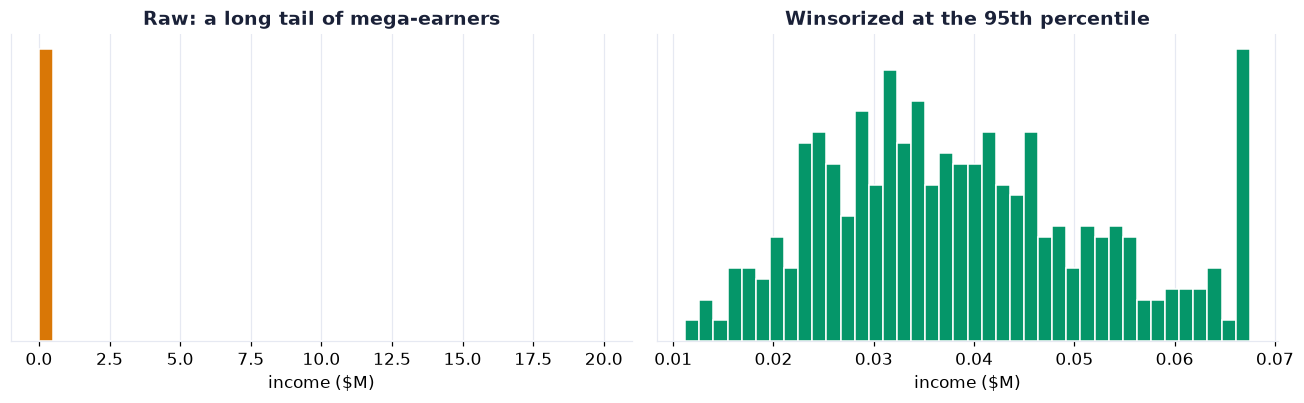

In [5]:
income = np.concatenate([rng.lognormal(10.5, 0.4, 480), [5e6, 8e6, 1.2e7, 2e7]])  # a few mega-earners

capped = np.clip(income, None, np.percentile(income, 95))   # winsorize the top 5%

print(f"raw     : mean {income.mean():12,.0f}   median {np.median(income):12,.0f}")
print(f"capped  : mean {capped.mean():12,.0f}   median {np.median(capped):12,.0f}")
print("The mean fell a lot; the median barely moved (it was robust all along).")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.hist(income/1e6, bins=40, color=AMBER, edgecolor="white"); a1.set_title("Raw: a long tail of mega-earners"); a1.set_yticks([]); a1.set_xlabel("income ($M)")
a2.hist(capped/1e6, bins=40, color=GREEN, edgecolor="white"); a2.set_title("Winsorized at the 95th percentile"); a2.set_yticks([]); a2.set_xlabel("income ($M)")
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · HIDDEN IN PLAIN SIGHT</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📐 A multivariate outlier</div>
<div style="color:#4a5578;margin-top:6px">Some outliers are normal on every single column and only impossible in combination, think a 7-foot, 100-pound person. Per-column IQR or z checks are blind to these; you need a two-variable view (a scatter) or a multivariate method.</div>
</div>

flagged by height alone (IQR)? True
flagged by weight alone (IQR)? False
Neither column flags it, yet the pair is clearly off the height-weight trend.


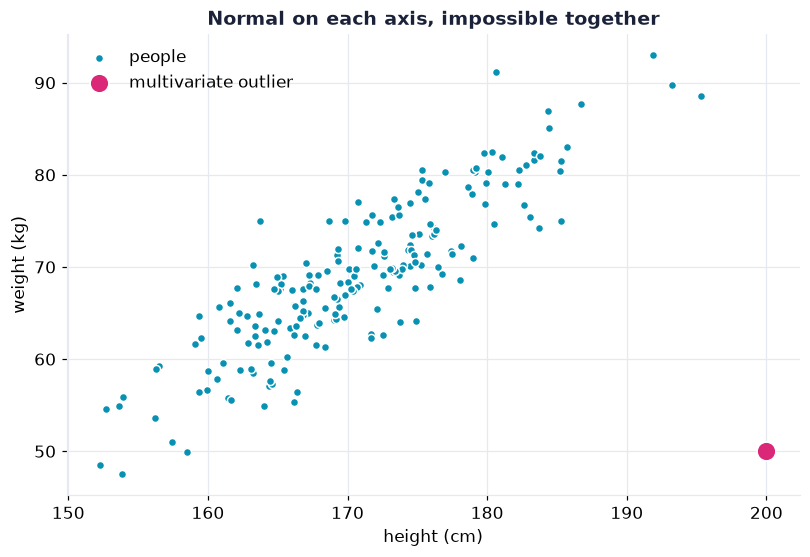

Beyond intro: Mahalanobis distance or sklearn IsolationForest / LocalOutlierFactor find these in many dimensions.


In [6]:
h = rng.normal(170, 8, 200)      # height cm
w = 0.9*(h-170) + 68 + rng.normal(0, 4, 200)   # weight correlated with height
h = np.append(h, 200); w = np.append(w, 50)     # tall AND very light: impossible together

def iqr_flags(a):
    q1,q3 = np.percentile(a,[25,75]); k=1.5*(q3-q1)
    return (a < q1-k) | (a > q3+k)

print(f"flagged by height alone (IQR)? {iqr_flags(h)[-1]}")
print(f"flagged by weight alone (IQR)? {iqr_flags(w)[-1]}")
print("Neither column flags it, yet the pair is clearly off the height-weight trend.")

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.scatter(h[:-1], w[:-1], color=CYAN, s=28, edgecolor="white", label="people")
ax.scatter([h[-1]],[w[-1]], color=PINK, s=150, edgecolor="white", zorder=5, label="multivariate outlier")
ax.set_xlabel("height (cm)"); ax.set_ylabel("weight (kg)")
ax.set_title("Normal on each axis, impossible together"); ax.legend()
plt.tight_layout(); plt.show()
print("Beyond intro: Mahalanobis distance or sklearn IsolationForest / LocalOutlierFactor find these in many dimensions.")

## 📦 Real-World Example: Package Weights
Four hundred package weights hiding two kinds of extreme: a few **genuine** heavy packages and a couple of data-entry **errors** (a 2 kg package typed as 240). We detect the extremes two ways, the robust **IQR fence** and a **z-score**, and see a classic trap: the giant errors inflate the standard deviation so much that the z-score rule barely flags anything, while the IQR rule catches them all.

median 1.99 kg   mean 3.19 kg   (the errors wreck the mean)
IQR fence [1.27, 2.74] -> flags 14 outliers
z-score rule |z|>3          -> flags 2 outliers   (the errors inflate the SD, so it misses the rest)


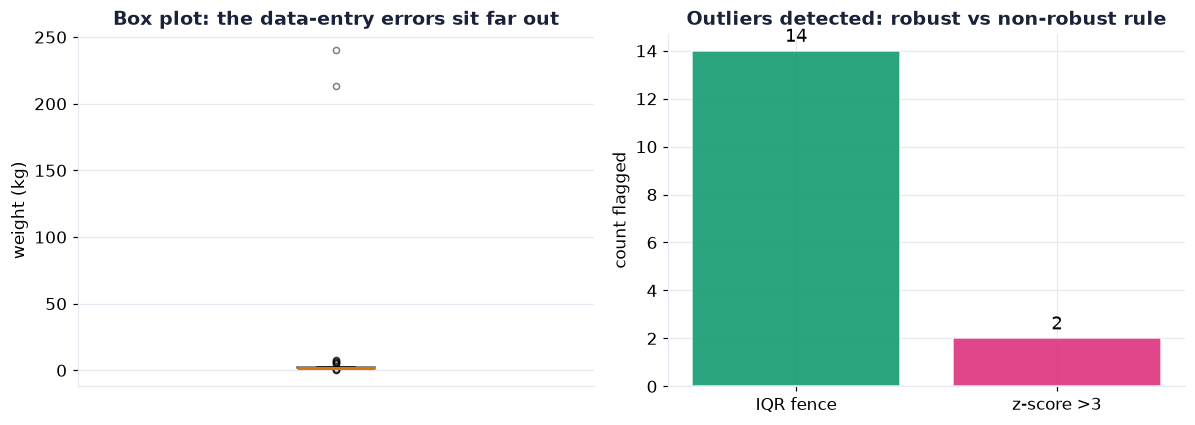

In [7]:
# --- Real-World beat: IQR vs z-score outlier detection ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    pkg = pd.read_excel("../../data/detecting-and-treating-outliers--package_weights.xlsx", sheet_name="Data")
except FileNotFoundError: pkg = pd.read_excel(BASE+"detecting-and-treating-outliers--package_weights.xlsx", sheet_name="Data")
w = pkg.weight_kg
q1, q3 = w.quantile([.25, .75]); iqr = q3 - q1; lo, hi = q1-1.5*iqr, q3+1.5*iqr
z = (w - w.mean()) / w.std()
iqr_out = ((w < lo) | (w > hi)).sum(); z_out = (z.abs() > 3).sum()
print(f"median {w.median():.2f} kg   mean {w.mean():.2f} kg   (the errors wreck the mean)")
print(f"IQR fence [{lo:.2f}, {hi:.2f}] -> flags {iqr_out} outliers")
print(f"z-score rule |z|>3          -> flags {z_out} outliers   (the errors inflate the SD, so it misses the rest)")
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].boxplot(w, patch_artist=True, boxprops=dict(facecolor=CYAN, alpha=0.6),
              medianprops=dict(color=AMBER, linewidth=2), flierprops=dict(marker="o", markersize=4, alpha=0.5))
ax[0].set_title("Box plot: the data-entry errors sit far out"); ax[0].set_ylabel("weight (kg)"); ax[0].set_xticks([])
bars = ax[1].bar(["IQR fence", "z-score >3"], [iqr_out, z_out], color=[GREEN, PINK], alpha=0.85, edgecolor="white")
ax[1].bar_label(bars, fmt="%d", padding=3, fontsize=12)
ax[1].set_title("Outliers detected: robust vs non-robust rule"); ax[1].set_ylabel("count flagged")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>The <b>IQR fence</b> (Q1-1.5xIQR, Q3+1.5xIQR) is robust and distribution-free; flagged is not the same as wrong.</li>
<li>The <b>plain z-score masks</b> big outliers (it inflates the SD); the <b>modified z</b> (median and MAD) is robust.</li>
<li>A single <b>leverage point</b> can swing a regression line, so investigate before deleting.</li>
<li><b>Capping / winsorizing</b> limits influence without deleting; or just use the <b>median and IQR</b>.</li>
<li><b>Multivariate outliers</b> are invisible to per-column checks; the treatment always depends on the cause.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>